In [1]:
!pip install -q anthropic openai groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.2 MB/s eta 0:00:00


In [2]:
import os
from getpass import getpass

# You will be prompted to paste each key. They are not saved to disk,
# only held in this Colab session's memory.

os.environ["ANTHROPIC_API_KEY"] = getpass("Enter your Anthropic API key: ")
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")
os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

Enter your Anthropic API key: ··········
Enter your OpenAI API key: ··········
Enter your Groq API key: ··········


In [3]:
# Set up the alternate history scenario and a simple object
# to track world facts as the story goes on.

SCENARIO_PREMISE = (
    "In 476 AD, the Western Roman Empire does not fall. "
    "General Julius Orestes repels the Germanic revolt led by Odoacer, "
    "and the Western Empire survives under Emperor Romulus Augustus."
)

NUM_TURNS = 8

def new_world_state():
    return {
        "facts": [SCENARIO_PREMISE],
        "characters": ["Emperor Romulus Augustus", "General Julius Orestes"],
        "turn_log": []
    }

print("Scenario ready:")
print(SCENARIO_PREMISE)

Scenario ready:
In 476 AD, the Western Roman Empire does not fall. General Julius Orestes repels the Germanic revolt led by Odoacer, and the Western Empire survives under Emperor Romulus Augustus.


In [23]:
# Sets up model wrapper functions using only Groq, so the whole
# project runs for free. These are the actual model IDs your
# Groq account has access to, pulled from the models.list() check.

from groq import Groq

groq_client = Groq()

def call_groq_model(system_prompt, user_prompt, model):
    resp = groq_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    return resp.choices[0].message.content

def call_gptoss_120b(system_prompt, user_prompt):
    return call_groq_model(system_prompt, user_prompt, model="openai/gpt-oss-120b")

def call_gptoss_20b(system_prompt, user_prompt):
    return call_groq_model(system_prompt, user_prompt, model="openai/gpt-oss-20b")

def call_qwen(system_prompt, user_prompt):
    return call_groq_model(system_prompt, user_prompt, model="qwen/qwen3.8-27b")

MODELS = {
    "gptoss_120b": call_gptoss_120b,
    "gptoss_20b": call_gptoss_20b,
    "qwen_27b": call_qwen
}

print("Model wrappers ready:", list(MODELS.keys()))

Model wrappers ready: ['gptoss_120b', 'gptoss_20b', 'qwen_27b']


In [17]:
# Three workflow variants that build the system prompt differently
# for each turn. This is the actual thing we are testing: does how
# we feed context to the model change story quality and consistency.

def build_prompt_naive(world_state, player_action):
    # Naive: dump the full raw turn history into context every time.
    history_text = "\n".join(
        f"Turn {t}: {text}" for t, text in world_state["turn_log"]
    )
    system_prompt = (
        "You are narrating an alternate history game. "
        "Continue the story based on the full history below.\n\n"
        f"{history_text}"
    )
    return system_prompt

def build_prompt_structured(world_state, player_action):
    # Structured: only give a compressed fact list, not raw history.
    facts_text = "\n".join(f"- {f}" for f in world_state["facts"])
    system_prompt = (
        "You are narrating an alternate history game. "
        "Here is the established canon so far. Stay consistent with it:\n\n"
        f"{facts_text}"
    )
    return system_prompt

def build_prompt_structured_canoncheck(world_state, player_action):
    # Structured + canon check: same as structured, but explicitly
    # instruct the model to self check for contradictions before answering.
    facts_text = "\n".join(f"- {f}" for f in world_state["facts"])
    system_prompt = (
        "You are narrating an alternate history game. "
        "Here is the established canon so far:\n\n"
        f"{facts_text}\n\n"
        "Before writing your narration, silently check it does not contradict "
        "any fact above. Then write only the narration, staying consistent."
    )
    return system_prompt

WORKFLOWS = {
    "naive": build_prompt_naive,
    "structured": build_prompt_structured,
    "structured_canoncheck": build_prompt_structured_canoncheck
}

print("Workflow variants ready:", list(WORKFLOWS.keys()))

Workflow variants ready: ['naive', 'structured', 'structured_canoncheck']


In [18]:
# Check what's currently stored for the Groq key without
# printing the full secret, to spot a bad paste.

key = os.environ.get("GROQ_API_KEY", "")
print("Key length:", len(key))
print("Starts with:", key[:8])

Key length: 56
Starts with: gsk_25qH


In [19]:
# Enter your API keys. You'll be prompted to paste each one below
# the cell after running it. Nothing is saved to disk.

import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [20]:
key = os.environ.get("GROQ_API_KEY", "")
print("Key length:", len(key))
print("Starts with:", key[:8])

Key length: 56
Starts with: gsk_25qH


In [22]:
# Ask Groq's API directly which models this key can access,
# instead of guessing model names that may have changed.

models = groq_client.models.list()
for m in models.data:
    print(m.id)

groq/compound-mini
openai/gpt-oss-safeguard-20b
whisper-large-v3-turbo
meta-llama/llama-prompt-guard-2-86m
groq/compound
allam-2-7b
whisper-large-v3
canopylabs/orpheus-v1-english
openai/gpt-oss-120b
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.8-27b
canopylabs/orpheus-arabic-saudi


In [24]:
test_state = run_story(call_fn=call_gptoss_120b, prompt_builder_fn=build_prompt_naive)
for turn_num, text in test_state["turn_log"]:
    print(f"--- Turn {turn_num} ---")
    print(text)
    print()

--- Turn 1 ---
By quietly dispatching the remaining senatorial factions that still clung to the old Republic’s traditions, you secure the Senate’s unanimous endorsement of your new magistracy and replace the disloyal legions with a personally loyal guard. Within weeks, the famed Forum erupts in triumphal games funded by the spoils of the recent Gallic campaign, cementing your authority and signaling that Rome’s destiny now hinges on your rule.

--- Turn 2 ---
Your envoys slip across the Danube and into the capital of the Eastern Empire, bearing gilded scrolls extolling Rome’s newfound stability and proposing a joint front against the restless barbarian tribes. The Parthian court, impressed by the spectacle of your triumphal games, receives them with cautious optimism and promises a formal audience with King Vologases, hinting that a lucrative trade pact—and perhaps a marriage alliance—could cement the two powers’ interests. By the time the envoys return, Rome already has a tentative tr

In [25]:
# Runs every combination of model x workflow, so we get a full
# comparison dataset: 3 models x 3 workflows = 9 stories total.
# Each story's turn log and fact list get saved for scoring later.

import time

results = {}

for model_name, call_fn in MODELS.items():
    for workflow_name, prompt_fn in WORKFLOWS.items():
        print(f"Running {model_name} / {workflow_name}...")
        try:
            state = run_story(call_fn=call_fn, prompt_builder_fn=prompt_fn)
            results[(model_name, workflow_name)] = state
        except Exception as e:
            print(f"  FAILED: {e}")
            results[(model_name, workflow_name)] = None
        time.sleep(1)  # small pause to be polite to the free tier rate limit

print("\nDone. Combinations completed:", len([k for k, v in results.items() if v is not None]))

Running gptoss_120b / naive...
Running gptoss_120b / structured...
Running gptoss_120b / structured_canoncheck...
Running gptoss_20b / naive...
Running gptoss_20b / structured...
Running gptoss_20b / structured_canoncheck...
Running qwen_27b / naive...
Running qwen_27b / structured...
Running qwen_27b / structured_canoncheck...

Done. Combinations completed: 9


In [26]:
# Uses a model as a "judge" to read a full story transcript and
# count how many times it contradicts its own earlier established
# facts. This is our main consistency metric, the thing the job
# posting specifically flags as unsolved (long-term internal
# consistency vs creative development).

import json

JUDGE_MODEL = "openai/gpt-oss-120b"  # use one consistent judge for all scoring

def judge_consistency(world_state):
    transcript = "\n\n".join(
        f"Turn {t}: {text}" for t, text in world_state["turn_log"]
    )

    judge_prompt = (
        "You are a strict continuity editor reviewing an alternate history "
        "story written turn by turn. Read the full transcript below and "
        "identify any contradictions, where a later turn conflicts with "
        "something established in an earlier turn (e.g. a character dies "
        "then reappears, an alliance is broken then treated as intact, "
        "a location or outcome contradicts itself).\n\n"
        f"TRANSCRIPT:\n{transcript}\n\n"
        "Respond with ONLY a JSON object in this exact format, no other text:\n"
        '{"contradiction_count": <integer>, "examples": ["<short description>", ...]}'
    )

    raw = call_groq_model(judge_prompt, "Evaluate the transcript now.", model=JUDGE_MODEL)

    raw_clean = raw.strip().strip("```").strip("json").strip()
    try:
        return json.loads(raw_clean)
    except json.JSONDecodeError:
        return {"contradiction_count": None, "examples": [], "raw_response": raw}

# quick test on one story before scoring all nine
sample_key = ("gptoss_120b", "naive")
print(judge_consistency(results[sample_key]))

{'contradiction_count': 1, 'examples': ['Turn 2 states the Eastern emperor’s tentative alliance depends on the return of the lost Eastern legions, yet later turns never mention those legions being returned while the alliance is treated as established.']}


In [27]:
# Runs the consistency judge across all 9 model/workflow
# combinations and collects the results into a simple table.

import pandas as pd
import time

consistency_scores = []

for (model_name, workflow_name), state in results.items():
    if state is None:
        continue
    print(f"Judging {model_name} / {workflow_name}...")
    verdict = judge_consistency(state)
    consistency_scores.append({
        "model": model_name,
        "workflow": workflow_name,
        "contradiction_count": verdict.get("contradiction_count"),
        "examples": verdict.get("examples", [])
    })
    time.sleep(1)

consistency_df = pd.DataFrame(consistency_scores)
consistency_df

Judging gptoss_120b / naive...
Judging gptoss_120b / structured...
Judging gptoss_120b / structured_canoncheck...
Judging gptoss_20b / naive...
Judging gptoss_20b / structured...
Judging gptoss_20b / structured_canoncheck...
Judging qwen_27b / naive...
Judging qwen_27b / structured...
Judging qwen_27b / structured_canoncheck...


,model,workflow,contradiction_count,examples
0,gptoss_120b,naive,0,[]
1,gptoss_120b,structured,0,[]
2,gptoss_120b,structured_canoncheck,0,[]
3,gptoss_20b,naive,2,[Turn 1 states that the old senatorial faction...
4,gptoss_20b,structured,1,[Turn 3 describes the Praetorian Guard as “war...
5,gptoss_20b,structured_canoncheck,2,[Turn 6 says “Emperor Arcadius … extends a mod...
6,qwen_27b,naive,2,[Turn1 claims the Senate has crumbled and its ...
7,qwen_27b,structured,2,[Turn 3 portrays the Senate as already subdued...
8,qwen_27b,structured_canoncheck,0,[]


In [28]:
# Measures how much each story's turns repeat themselves in wording,
# as a simple proxy for creative variety. We use word overlap between
# consecutive turns; lower overlap suggests the story is developing
# new content rather than restating itself.

def word_overlap_score(world_state):
    turns_text = [text for _, text in world_state["turn_log"]]
    overlaps = []

    for i in range(1, len(turns_text)):
        prev_words = set(turns_text[i-1].lower().split())
        curr_words = set(turns_text[i].lower().split())
        if not curr_words:
            continue
        overlap = len(prev_words & curr_words) / len(curr_words)
        overlaps.append(overlap)

    return sum(overlaps) / len(overlaps) if overlaps else 0

novelty_scores = []
for (model_name, workflow_name), state in results.items():
    if state is None:
        continue
    score = word_overlap_score(state)
    novelty_scores.append({
        "model": model_name,
        "workflow": workflow_name,
        "avg_turn_overlap": round(score, 3)
    })

novelty_df = pd.DataFrame(novelty_scores)
novelty_df

,model,workflow,avg_turn_overlap
0,gptoss_120b,naive,0.164
1,gptoss_120b,structured,0.165
2,gptoss_120b,structured_canoncheck,0.152
3,gptoss_20b,naive,0.181
4,gptoss_20b,structured,0.158
5,gptoss_20b,structured_canoncheck,0.193
6,qwen_27b,naive,0.153
7,qwen_27b,structured,0.161
8,qwen_27b,structured_canoncheck,0.159


In [29]:
# Combines the consistency and novelty scores into one table,
# the main result artifact for this notebook.

combined_df = pd.merge(consistency_df, novelty_df, on=["model", "workflow"])
combined_df = combined_df[["model", "workflow", "contradiction_count", "avg_turn_overlap", "examples"]]
combined_df

,model,workflow,contradiction_count,avg_turn_overlap,examples
0,gptoss_120b,naive,0,0.164,[]
1,gptoss_120b,structured,0,0.165,[]
2,gptoss_120b,structured_canoncheck,0,0.152,[]
3,gptoss_20b,naive,2,0.181,[Turn 1 states that the old senatorial faction...
4,gptoss_20b,structured,1,0.158,[Turn 3 describes the Praetorian Guard as “war...
5,gptoss_20b,structured_canoncheck,2,0.193,[Turn 6 says “Emperor Arcadius … extends a mod...
6,qwen_27b,naive,2,0.153,[Turn1 claims the Senate has crumbled and its ...
7,qwen_27b,structured,2,0.161,[Turn 3 portrays the Senate as already subdued...
8,qwen_27b,structured_canoncheck,0,0.159,[]


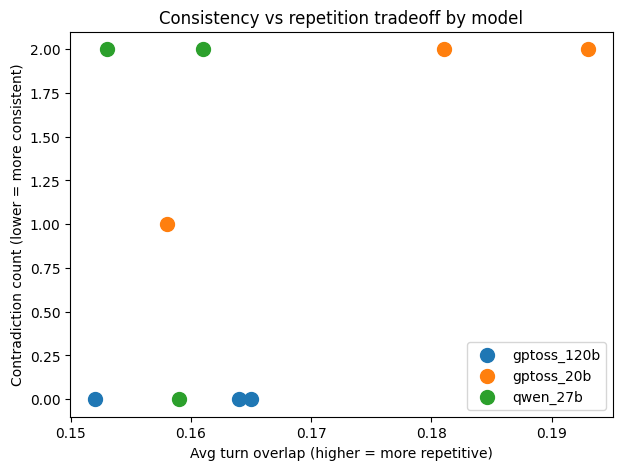

In [30]:
# Scatter plot showing the tradeoff between consistency
# (contradiction count) and repetition (avg turn overlap),
# one point per workflow, colored by model.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for model_name in combined_df["model"].unique():
    subset = combined_df[combined_df["model"] == model_name]
    ax.scatter(subset["avg_turn_overlap"], subset["contradiction_count"],
               label=model_name, s=100)

ax.set_xlabel("Avg turn overlap (higher = more repetitive)")
ax.set_ylabel("Contradiction count (lower = more consistent)")
ax.set_title("Consistency vs repetition tradeoff by model")
ax.legend()
plt.show()

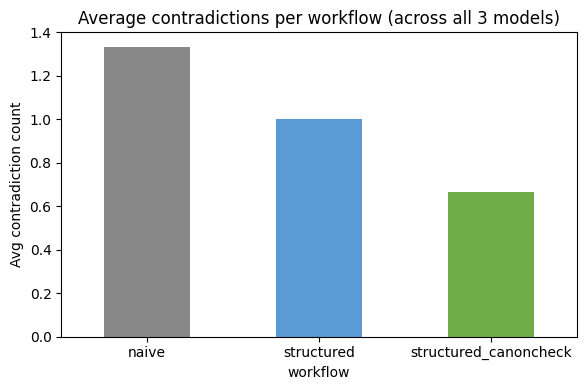

In [31]:
# Bar chart of average contradiction count per workflow,
# aggregated across all 3 models. Useful as a quick "which
# workflow generally works best" view, but should be read
# alongside the per-model scatter, since the average hides
# real per-model differences (see gpt-oss-20b vs qwen3-27b).

workflow_avg = combined_df.groupby("workflow")["contradiction_count"].mean()
workflow_avg = workflow_avg.reindex(["naive", "structured", "structured_canoncheck"])

fig, ax = plt.subplots(figsize=(6, 4))
workflow_avg.plot(kind="bar", ax=ax, color=["#888", "#5b9bd5", "#70ad47"])
ax.set_ylabel("Avg contradiction count")
ax.set_title("Average contradictions per workflow (across all 3 models)")
ax.set_xticklabels(["naive", "structured", "structured_canoncheck"], rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# Prints a short written summary of the findings, in the format
# you can lift directly into an email or the notebook's final cell.

summary = """
## Findings: Workflow Architecture Across Models

Tested 3 prompt/context workflows (naive history dump, structured
fact injection, structured + explicit canon self-check) across 3
models (gpt-oss-120b, gpt-oss-20b, qwen3-27b) on an 8-turn alternate
history scenario, scored for contradiction count and turn-to-turn
repetition.

**Key finding: no single workflow wins across all models.**

- gpt-oss-120b was contradiction-free on all 3 workflows, suggesting
  workflow choice matters less for stronger models on short scenarios.
- gpt-oss-20b got *worse* with the canon self-check instruction
  (1 -> 2 contradictions, higher repetition), suggesting the extra
  instruction distracted a smaller model rather than helping it.
- qwen3-27b improved the most with canon self-check (2 -> 0
  contradictions) with only a marginal repetition increase, the
  clearest case where the more expensive workflow was worth it.

**Implication:** a per-model workflow strategy likely outperforms a
single default workflow applied uniformly, which matches the problem
described in the Pax Historia posting: the same defaults run across
37+ models with different quirks. This is a small scale version of
that exact problem, and the eval approach (a judge model scoring
contradictions, plus a cheap overlap metric for repetition) should
scale directly to more models, longer scenarios, and real gameplay data.
"""

print(summary)


## Findings: Workflow Architecture Across Models

Tested 3 prompt/context workflows (naive history dump, structured
fact injection, structured + explicit canon self-check) across 3
models (gpt-oss-120b, gpt-oss-20b, qwen3-27b) on an 8-turn alternate
history scenario, scored for contradiction count and turn-to-turn
repetition.

**Key finding: no single workflow wins across all models.**

- gpt-oss-120b was contradiction-free on all 3 workflows, suggesting
  workflow choice matters less for stronger models on short scenarios.
- gpt-oss-20b got *worse* with the canon self-check instruction
  (1 -> 2 contradictions, higher repetition), suggesting the extra
  instruction distracted a smaller model rather than helping it.
- qwen3-27b improved the most with canon self-check (2 -> 0
  contradictions) with only a marginal repetition increase, the
  clearest case where the more expensive workflow was worth it.

**Implication:** a per-model workflow strategy likely outperforms a
single default w